In [24]:
from google.colab import drive

ValueError: Mountpoint must not already contain files

In [ ]:
!pip install retina-face deepface opencv-python

In [ ]:
# --- Import libraries ---
import os
import pandas as pd
from deepface import DeepFace
import numpy as np
import pickle  # Using pickle for easier loading/saving of embeddings
from scipy.spatial.distance import cosine

# --- Automatically create Project folders in Google Drive ---
BASE_DIR = "/content/drive/MyDrive/Project AI"
FACES_DIR = os.path.join(BASE_DIR, "FacesFramed")

# Create the folders if they don't exist
os.makedirs(FACES_DIR, exist_ok=True)

print("✅ Verified or created folders:")
print(" -", BASE_DIR)
print(" -", FACES_DIR)

# --- Define constants for your student project ---
STUDENT_FACES_DIR = FACES_DIR
MODEL_NAME = 'ArcFace'  # Or 'VGG-Face', 'Facenet', etc.
DATABASE_FILE = os.path.join(BASE_DIR, "student_database.pkl")

print("\n✅ Setup complete.")
print("Student Faces Directory:", STUDENT_FACES_DIR)
print("Database will be saved to:", DATABASE_FILE)



✅ Verified or created folders:
 - /content/drive/MyDrive/Project AI
 - /content/drive/MyDrive/Project AI/FacesFramed

✅ Setup complete.
Student Faces Directory: /content/drive/MyDrive/Project AI/FacesFramed
Database will be saved to: /content/drive/MyDrive/Project AI/student_database.pkl


In [ ]:
def extract_label_from_filename(filename):
    """
    Extracts (student_name, student_id) from filename.
    Accepts:
      - 'StudentName_ID.ext'
      - 'StudentName_ID_Number.ext'  (Number is per-image index; ignored)
    Returns: (student_name, student_id) or None if format is invalid.
    """
    try:
        base = os.path.splitext(filename)[0]
        parts = base.split('_')

        if len(parts) < 2:
            print(f"    - Warning: '{filename}' does not match expected 'Name_ID[_Number].ext' format.")
            return None

        maybe_num = parts[-1]
        if maybe_num.isdigit() and len(parts) >= 3:
            student_id = parts[-2].strip()
            student_name = "_".join(parts[:-2]).strip()
        else:
            student_id = parts[-1].strip()
            student_name = "_".join(parts[:-1]).strip()

        student_name = student_name.replace('_', ' ').strip()

        if student_name and student_id:
            return student_name, student_id

        print(f"    - Warning: Missing student name or ID for file {filename}")
        return None
    except Exception as e:
        print(f"    - Error parsing filename {filename}: {e}")
        return None


In [ ]:
def generate_student_database_flat(image_folder, model_name):
    """
    Scans a single folder, extracts student name + ID from filenames (ignoring trailing per-image number),
    generates embeddings, and returns:
      - labels:     list of student_id (classification target)
      - names:      list of student_name (for readability)
      - embeddings: list of 512-d np arrays
    """
    database = {'labels': [], 'names': [], 'embeddings': []}
    error_files = []

    if not os.path.isdir(image_folder):
        print(f"Error: Directory not found - {image_folder}")
        return None, None

    image_files = [f for f in os.listdir(image_folder)
                   if os.path.isfile(os.path.join(image_folder, f))
                   and f.lower().endswith(('.png', '.jpg', '.jpeg'))]

    if not image_files:
        print(f"Error: No image files (.png, .jpg, .jpeg) found in {image_folder}")
        return None, None

    print(f"Found {len(image_files)} potential image files. Processing...")

    processed_count = 0
    for i, img_file in enumerate(image_files):
        print(f"  Processing file {i+1}/{len(image_files)}: {img_file}", end='\r')

        img_path = os.path.join(image_folder, img_file)

        parsed = extract_label_from_filename(img_file)
        if parsed is None:
            error_files.append(img_path + " (Invalid filename format)")
            continue
        student_name, student_id = parsed  # number is intentionally ignored

        try:
            embedding_objs = DeepFace.represent(
                img_path=img_path,
                model_name=model_name,
                enforce_detection=True,
                detector_backend='mtcnn'
            )

            if embedding_objs and len(embedding_objs) > 0:
                embedding = embedding_objs[0]["embedding"]
                database['labels'].append(student_id)
                database['names'].append(student_name)
                database['embeddings'].append(np.array(embedding))
                processed_count += 1
            else:
                error_files.append(img_path + " (No face/embedding)")

        except ValueError as ve:
            error_files.append(img_path + f" ({ve})")
        except Exception as e:
            error_files.append(img_path + f" ({e})")

    print(f"\nFinished processing. Successfully generated {processed_count} embeddings.")

    if not database['labels']:
        print("Error: No embeddings were successfully generated.")
        return None, error_files

    if error_files:
        print(f"Encountered issues with {len(error_files)} files.")

    return database, error_files


In [ ]:
# --- Main Execution ---
if __name__ == "__main__":
    print("Starting student database creation from flat directory...")
    print(f"Reading images from: {STUDENT_FACES_DIR}")
    print(f"Expected filename format: 'StudentName_ID_Number.extension'")
    # --- Crucial Step: Adapt the STUDENT_FACES_DIR path above ---
    if not os.path.exists(STUDENT_FACES_DIR):
         print(f"\nERROR: The directory '{STUDENT_FACES_DIR}' does not exist.")
         print("Please update the STUDENT_FACES_DIR variable in the script.")
    else:
        # Call the modified function
        student_data, errors = generate_student_database_flat(STUDENT_FACES_DIR, MODEL_NAME)

        if student_data:
            # Save the database using pickle
            try:
                with open(DATABASE_FILE, 'wb') as f:
                    pickle.dump(student_data, f)
                print(f"\nStudent database saved successfully to {DATABASE_FILE}")
            except Exception as e:
                print(f"\nError saving database file: {e}")
        else:
            print("\nDatabase creation failed.")


Starting student database creation from flat directory...
Reading images from: /content/drive/MyDrive/Project AI/FacesFramed
Expected filename format: 'StudentName_ID_Number.extension'
Error: No image files (.png, .jpg, .jpeg) found in /content/drive/MyDrive/Project AI/FacesFramed

Database creation failed.


In [ ]:
import pickle

# Load your database from Drive
DATABASE_FILE = "/content/drive/MyDrive/Project AI/student_database.pkl"

with open(DATABASE_FILE, "rb") as f:
    student_db = pickle.load(f)

# Check what’s inside
print(student_db.keys())
print("Number of entries:", len(student_db["labels"]))
print("First 3 entries:")
for i in range(20):
    print(student_db["names"][i], "-", student_db["labels"][i])


dict_keys(['labels', 'names', 'embeddings'])
Number of entries: 57
First 3 entries:
YazanKhouli - 100064788
YazanKhouli - 100064788
YazanKhouli - 100064788
YazanKhouli - 100064788
YazanKhouli - 100064788
YazanKhouli - 100064788
YazanKhouli - 100064788
YazanKhouli - 100064788
YazanKhouli - 100064788
YazanKhouli - 100064788
YazanKhouli - 100064788
YazanKhouli - 100064788
YazanKhouli - 100064788
YazanKhouli - 100064788
YazanKhouli - 100064788
YazanKhouli - 100064788
NoorLaz - 100064785
NoorLaz - 100064785
NoorLaz - 100064785
NoorLaz - 100064785


In [ ]:
from google.colab import files
uploaded = files.upload()

In [ ]:
import os
import pickle
import numpy as np
from deepface import DeepFace
from scipy.spatial.distance import cosine

# --- Configuration ---
# Database file created by your database-creation script
DATABASE_FILE = '/content/drive/MyDrive/Project AI/student_database.pkl'

# Model used for face recognition
MODEL_NAME = 'ArcFace'

# Face detector backend DeepFace should use internally
DETECTOR_BACKEND = 'mtcnn'

# Distance threshold - If the closest match distance is above this, classify as "Unknown".
# Lower threshold = stricter matching.
DISTANCE_THRESHOLD = 0.68


# --- Helper Functions ---

def load_database(database_path):
    """Loads the student embeddings, labels (IDs), and names from the pickle file."""
    if not os.path.exists(database_path):
        print(f"Error: Database file not found at '{database_path}'")
        print("Please run the database creation script first.")
        return None
    try:
        with open(database_path, 'rb') as f:
            database = pickle.load(f)
        print(f"Loaded database with {len(database.get('embeddings', []))} known face entries.")
        # Ensure embeddings are numpy arrays (important for distance calculations)
        if 'embeddings' in database and isinstance(database['embeddings'], list):
            database['embeddings'] = [np.array(e) for e in database['embeddings']]
        return database
    except Exception as e:
        print(f"Error loading database file '{database_path}': {e}")
        return None


def find_closest_candidate(input_embedding, database):
    """
    Calculates cosine distances and returns the details of the closest known candidate.
    Does NOT apply threshold logic; it just finds the physically closest face.
    Returns: (closest_name, closest_id, min_distance)
    """
    if not database or 'embeddings' not in database or not database['embeddings']:
        # Handle empty database case gracefully
        return "No Candidate", "No ID", float('inf')

    known_embeddings = database['embeddings']
    known_labels = database['labels']
    known_names = database.get('names', []) # Use an empty list as default if 'names' key is missing

    distances = [cosine(input_embedding, known_emb) for known_emb in known_embeddings]

    if not distances:
        return "No Candidate", "No ID", float('inf')

    min_idx = np.argmin(distances)
    min_distance = distances[min_idx]

    closest_id = known_labels[min_idx]
    closest_name = known_names[min_idx] if known_names else "Unknown Name" # Fallback if names are truly missing

    return closest_name, closest_id, min_distance


def identify_student_in_image(image_path, database, model_name, detector, threshold):
    """
    Detects a face in the input image, extracts its embedding,
    and identifies the closest match from the database.
    """
    if not os.path.exists(image_path):
        print(f"Error: Input image not found at '{image_path}'")
        return None, None

    try:
        # Use DeepFace.represent to detect a face and get its embedding.
        print(f"Analyzing '{image_path}' using {model_name} model and {detector} detector...")
        embedding_objs = DeepFace.represent(
            img_path=image_path,
            model_name=model_name,
            detector_backend=detector,
            enforce_detection=True  # ensures it tries to find a face
        )

        # If detection is successful, represent returns a list of dictionaries
        if not embedding_objs or len(embedding_objs) == 0:
            print(f"Error: No face embedding could be extracted from '{image_path}'.")
            return None, None

        input_embedding = np.array(embedding_objs[0]["embedding"])
        print("Face detected and embedding extracted successfully.")

        # Find the closest candidate (no threshold applied yet)
        closest_name, closest_id, min_distance = find_closest_candidate(input_embedding, database)

        print(f"Closest match distance: {min_distance:.4f}")

        # Apply threshold for logging/display messages
        if min_distance <= threshold:
            print(f"Match found: {closest_name} (ID: {closest_id}) (within threshold {threshold})")
        else:
            print(f"No confident match found (Closest distance {min_distance:.4f} > threshold {threshold}). Closest is {closest_name} (ID: {closest_id})")

        # Always return the closest name, ID, and its distance, regardless of threshold for run_evaluation
        return (closest_name, closest_id), min_distance

    except ValueError as ve:
        # Often means no face was detected by the detector backend
        print(f"\nError: Could not process image '{image_path}'.")
        print(f"  Reason: {ve}")
        print(f"  (This often means no face was detected by the '{detector}' backend).")
        print(f"  Try a different detector backend if a face is present.")
        return None, None
    except Exception as e:
        print(f"\nAn unexpected error occurred while processing '{image_path}': {e}")
        return None, None


# --- Main Execution ---
if __name__ == "__main__":
    print("--- Student Identification Tool ---")

    # 1. Load the student database
    student_db = load_database(DATABASE_FILE)

    if student_db:
        # 2. Get input image path from user
        input_image_path = input("Enter the path to the image file for identification: ")

        # 3. Perform identification
        identified_info, confidence_distance = identify_student_in_image(
            input_image_path,
            student_db,
            MODEL_NAME,
            DETECTOR_BACKEND,
            DISTANCE_THRESHOLD
        )

        # 4. Print the final result
        print("\n--- Identification Result ---")
        if identified_info is not None:
            # identified_info is now always (name, id) if a face was detected
            name, sid = identified_info
            print(f"Identified Student: {name} (ID: {sid})")
            print(f"Distance Score: {confidence_distance:.4f} (Cosine distance, lower is better)")
            # Add check for confidence for console output if needed here
            if confidence_distance > DISTANCE_THRESHOLD:
                print(f"(Note: This match is not considered confident as distance {confidence_distance:.4f} > threshold {DISTANCE_THRESHOLD})")
        else:
            print("Identification failed. See errors above.")
        print("---------------------------")
    else:
        print("Exiting due to database loading failure.")

--- Student Identification Tool ---
Loaded database with 28 known face entries.
Enter the path to the image file for identification: /content/drive/MyDrive/Project AI/testimages/tsttaylor.png
Analyzing '/content/drive/MyDrive/Project AI/testimages/tsttaylor.png' using ArcFace model and mtcnn detector...
Face detected and embedding extracted successfully.
Closest match distance: 0.8790
No confident match found (Closest distance 0.8790 > threshold 0.68). Closest is NoorLaz (ID: 100064785)

--- Identification Result ---
Identified Student: NoorLaz (ID: 100064785)
Distance Score: 0.8790 (Cosine distance, lower is better)
(Note: This match is not considered confident as distance 0.8790 > threshold 0.68)
---------------------------


In [ ]:
# --- Student Identification Tool (prints Name + ID; proper Unknown handling) ---

import os
import pickle
import numpy as np
from deepface import DeepFace
from scipy.spatial.distance import cosine

# --- Configuration ---
DATABASE_FILE = '/content/drive/MyDrive/Project AI/student_database.pkl'
MODEL_NAME = 'ArcFace'
DETECTOR_BACKEND = 'mtcnn'
DISTANCE_THRESHOLD = 0.68  # lower = stricter

# --- Helpers ---

def load_database(database_path):
    """Loads the student embeddings and labels from the pickle file."""
    if not os.path.exists(database_path):
        print(f"Error: Database file not found at '{database_path}'")
        print("Please run the database creation script first.")
        return None
    try:
        with open(database_path, 'rb') as f:
            database = pickle.load(f)
        print(f"Loaded database with {len(database.get('embeddings', []))} known face entries.")
        # Ensure embeddings are numpy arrays
        if 'embeddings' in database and isinstance(database['embeddings'], list):
            database['embeddings'] = [np.array(e) for e in database['embeddings']]
        return database
    except Exception as e:
        print(f"Error loading database: {e}")
        return None


def get_name_for_id(database, student_id):
    """
    Look up the first name corresponding to a given student ID in the database.
    Returns a string (or None if not found / names missing).
    """
    if not database or 'labels' not in database:
        return None
    labels = database['labels']
    names  = database.get('names', None)
    if names is None:
        return None
    try:
        idx = labels.index(student_id)
        return names[idx]
    except ValueError:
        return None


def find_closest_match(input_embedding, database, threshold):
    """
    Compare input embedding with all known embeddings.
    Returns:
      - student_id or "Unknown"
      - distance value
      - closest_info tuple (name, id) if Unknown
    """
    if not database or 'embeddings' not in database or not database['embeddings']:
        print("Error: Empty or invalid database.")
        return "Error", float('inf'), None

    known_embeddings = database['embeddings']
    known_ids = database['labels']
    known_names = database.get('names', [])

    distances = [cosine(input_embedding, emb) for emb in known_embeddings]
    if not distances:
        return "Unknown", float('inf'), None

    min_idx = int(np.argmin(distances))
    min_distance = float(distances[min_idx])

    if min_distance <= threshold:
        # Confident match
        return str(known_ids[min_idx]), min_distance, None
    else:
        # Too far → Unknown, but keep note of closest
        closest_name = None
        if isinstance(known_names, list) and len(known_names) > min_idx:
            closest_name = known_names[min_idx]
        closest_id = str(known_ids[min_idx])
        return "Unknown", min_distance, (closest_name, closest_id)


def identify_student_in_image(image_path, database, model_name, detector, threshold):
    """
    Detects a face, extracts embedding, and identifies student or Unknown.
    Returns:
      - student_id_or_unknown (str)
      - distance (float)
      - closest_info (tuple or None)
    """
    if not os.path.exists(image_path):
        print(f"Error: Image not found at '{image_path}'")
        return None, None, None

    try:
        print(f"Analyzing '{image_path}' using {model_name} model and {detector} detector...")
        embedding_objs = DeepFace.represent(
            img_path=image_path,
            model_name=model_name,
            detector_backend=detector,
            enforce_detection=True
        )

        if not embedding_objs:
            print("Error: No face embedding extracted.")
            return None, None, None

        input_embedding = np.array(embedding_objs[0]["embedding"])
        print("Face detected and embedding extracted successfully.")

        student_id, distance, closest_info = find_closest_match(input_embedding, database, threshold)
        print(f"Closest match distance: {distance:.4f}")

        if student_id == "Unknown":
            if closest_info:
                cname, cid = closest_info
                if cname:
                    print(f"No confident match found (distance {distance:.4f} > {threshold}). Closest is {cname} (ID: {cid}).")
                else:
                    print(f"No confident match found (distance {distance:.4f} > {threshold}). Closest ID: {cid}.")
        else:
            print(f"Match found: Student ID '{student_id}' (within threshold {threshold}).")

        return student_id, distance, closest_info

    except ValueError as ve:
        print(f"\nError: Could not process image '{image_path}'. Reason: {ve}")
        return None, None, None
    except Exception as e:
        print(f"\nUnexpected error while processing '{image_path}': {e}")
        return None, None, None


# --- Main Execution ---
if __name__ == "__main__":
    print("--- Student Identification Tool ---")

    # Load student database
    student_db = load_database(DATABASE_FILE)

    if student_db:
        # Ask user for test image
        input_image_path = input("Enter the path to the image file for identification: ")

        # Perform identification
        identified_id, confidence_distance, closest_info = identify_student_in_image(
            input_image_path,
            student_db,
            MODEL_NAME,
            DETECTOR_BACKEND,
            DISTANCE_THRESHOLD
        )

        # --- Result Output ---
        print("\n--- Identification Result ---")
        if identified_id is None:
            print("Identification failed. See errors above.")
        elif identified_id == "Unknown":
            print("Identified Student: Unknown")
            print(f"Distance Score: {confidence_distance:.4f} (Cosine distance, lower is better)")
            if closest_info:
                cname, cid = closest_info
                hint = f"{cname} (ID: {cid})" if cname else f"ID: {cid}"
                print(f"(Note: This match is not confident; closest match is {hint})")
        else:
            # 🔹 Look up the name for the matched ID and print both
            identified_name = get_name_for_id(student_db, identified_id) or "Unknown Name"
            print(f"Identified Student: {identified_name} (ID: {identified_id})")
            print(f"Distance Score: {confidence_distance:.4f} (Cosine distance, lower is better)")
        print("---------------------------")
    else:
        print("Exiting due to database loading failure.")



25-11-19 10:46:04 - Directory /root/.deepface has been created
25-11-19 10:46:04 - Directory /root/.deepface/weights has been created
--- Student Identification Tool ---
Error: Database file not found at '/content/drive/MyDrive/Project AI/student_database.pkl'
Please run the database creation script first.
Exiting due to database loading failure.


Evaluating student face recognition system (force closest match)…
Loaded database with 57 embeddings.
Evaluating AbdelrahmanKhaled_100064694_1.jpeg (1/37)
Evaluating AbdelrahmanKhaled_100064694_2.jpeg (2/37)
Evaluating AbdelrahmanKhaled_100064694_3.jpeg (3/37)
Evaluating AbdelrahmanKhaled_100064694_4.jpeg (4/37)
Evaluating AbdelrahmanKhaled_100064694_5.jpeg (5/37)
Evaluating AbdelrahmanKhaled_100064694_6.jpeg (6/37)
Evaluating AbdelrahmanKhaled_100064694_7.jpeg (7/37)
Evaluating AhmedEltayeb_100066739_1.jpg (8/37)
Evaluating AhmedEltayeb_100066739_2.jpg (9/37)
Evaluating AhmedEltayeb_100066739_3.jpg (10/37)
Evaluating AhmedEltayeb_100066739_4.jpg (11/37)
Evaluating AhmedEltayeb_100066739_5.jpg (12/37)
Evaluating HussainAoudi_100066740_1.jpg (13/37)
Evaluating HussainAoudi_100066740_2.jpg (14/37)
Evaluating HussainAoudi_100066740_3.jpg (15/37)
Evaluating HussainAoudi_100066740_4.jpg (16/37)
Evaluating HusseinBassam_100066678_1.jpg (17/37)
Evaluating HusseinBassam_100066678_2.jpg (18/37)

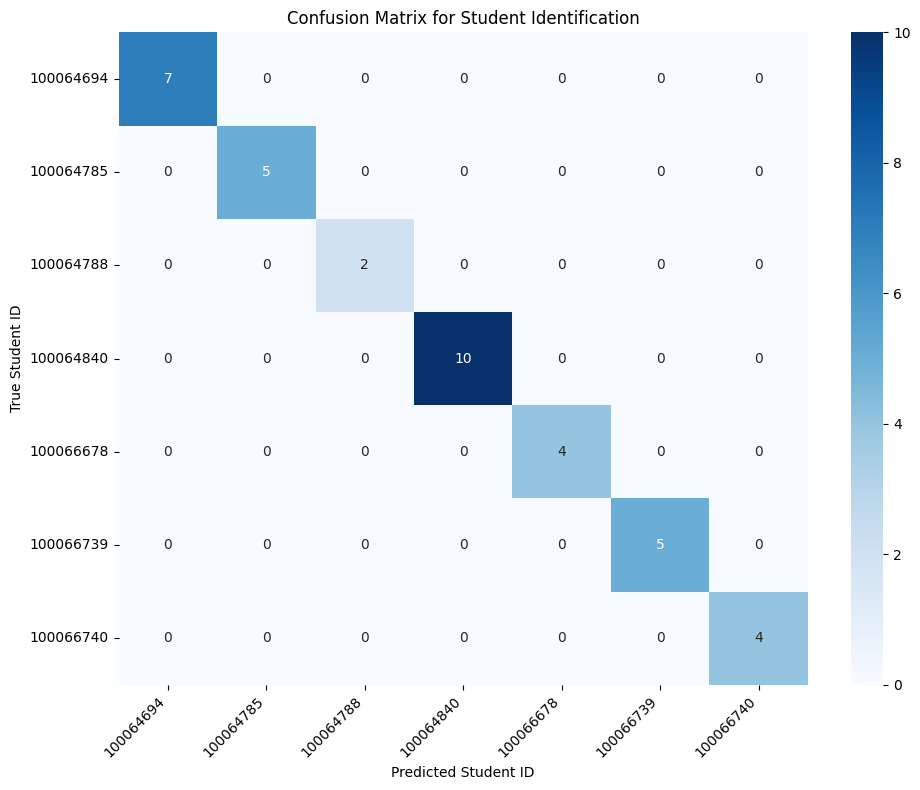

In [ ]:
# ===== Student Identification: Force-Closest Confusion Matrix (IDs only) =====

import os
import re
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial.distance import cosine
from sklearn.metrics import confusion_matrix, classification_report
from deepface import DeepFace
import pickle

# ----------------- CONFIG -----------------
DATABASE_FILE    = '/content/drive/MyDrive/Project AI/student_database.pkl'
TEST_IMAGE_DIR   = '/content/drive/MyDrive/Project AI/confusionMatrixImages'
MODEL_NAME       = 'ArcFace'
DETECTOR_BACKEND = 'mtcnn'   # 'retinaface' is also strong
# ------------------------------------------

# ---------- Utilities ----------
def load_database(database_path):
    if not os.path.exists(database_path):
        print(f"Error: DB not found at '{database_path}'"); return None
    with open(database_path, 'rb') as f:
        db = pickle.load(f)
    # ensure numpy arrays
    if 'embeddings' in db and isinstance(db['embeddings'], list):
        db['embeddings'] = [np.array(e) for e in db['embeddings']]
    print(f"Loaded database with {len(db.get('embeddings', []))} embeddings.")
    return db

def extract_label_from_filename(filename):
    """
    Expected filename: StudentName_ID_Number.ext
    Returns (name, id) or None if bad format.
    """
    try:
        stem = os.path.splitext(filename)[0]
        parts = stem.rsplit('_', 2)  # name, id, number
        if len(parts) != 3: return None
        name, sid, _num = parts
        name = name.strip()
        sid  = sid.strip()
        if not name or not sid: return None
        return (name, sid)
    except:
        return None

# ---------- Force-Closest Identification ----------
def _closest_id_from_embedding(input_embedding, database):
    embs = database['embeddings']
    ids  = database['labels']
    dists = [cosine(input_embedding, e) for e in embs]
    min_idx = int(np.argmin(dists))
    return str(ids[min_idx]), float(dists[min_idx])

def identify_student_in_image_closest(image_path, database, model_name, detector):
    if not os.path.exists(image_path):
        print(f"Error: file not found: {image_path}")
        return None, None
    try:
        emb_objs = DeepFace.represent(
            img_path=image_path,
            model_name=model_name,
            detector_backend=detector,
            enforce_detection=True
        )
        if not emb_objs: return None, None
        emb = np.array(emb_objs[0]["embedding"])
        return _closest_id_from_embedding(emb, database)
    except Exception as e:
        print(f"identify_student_in_image_closest error: {e}")
        return None, None

# ---------- Evaluation (IDs only, no Unknown) ----------
def _force_id(x):
    if x is None: return None
    if isinstance(x, (list, tuple)) and x: x = x[-1]
    s = str(x).strip()
    if s.lower() in {"unknown", "error"}: return None
    if s.isdigit(): return s
    m = re.findall(r"\d+", s)
    return m[-1] if m else None

def run_evaluation_force_closest(test_dir, database, model_name, detector):
    y_true, y_pred = [], []

    img_files = [f for f in os.listdir(test_dir)
                 if os.path.isfile(os.path.join(test_dir, f))
                 and f.lower().endswith(('.png', '.jpg', '.jpeg'))]

    for i, fname in enumerate(sorted(img_files)):
        print(f"Evaluating {fname} ({i+1}/{len(img_files)})")
        parsed = extract_label_from_filename(fname)  # -> (name, id)
        if not parsed: continue
        _, sid = parsed
        sid = _force_id(sid)
        # drop explicit unknowns in ground-truth like 000000/Unknown
        if sid is None or sid == "000000":
            continue

        img_path = os.path.join(test_dir, fname)

        pred_sid, dist = identify_student_in_image_closest(
            img_path, database, model_name, detector
        )
        pred_sid = _force_id(pred_sid)
        if pred_sid is None:  # skip errors
            continue

        y_true.append(sid)
        y_pred.append(pred_sid)

    return y_true, y_pred

def plot_confusion_matrix_ids(y_true, y_pred, labels):
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    fig_w = max(10, int(len(labels) * 0.8)) if labels else 10
    fig_h = max(8, int(len(labels) * 0.6)) if labels else 8
    plt.figure(figsize=(fig_w, fig_h))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels, yticklabels=labels)
    plt.title('Confusion Matrix for Student Identification')
    plt.xlabel('Predicted Student ID')
    plt.ylabel('True Student ID')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

# ---------- MAIN ----------
if __name__ == "__main__":
    print("Evaluating student face recognition system (force closest match)…")

    db = load_database(DATABASE_FILE)
    if not db:
        raise SystemExit

    y_true, y_pred = run_evaluation_force_closest(
        TEST_IMAGE_DIR, db, MODEL_NAME, DETECTOR_BACKEND
    )

    # ensure clean scalars
    y_true = [str(x) for x in y_true]
    y_pred = [str(x) for x in y_pred]

    if y_true and y_pred:
        print("\nClassification Report (IDs):")
        print(classification_report(y_true, y_pred))

        unique_ids = sorted(set(y_true + y_pred), key=lambda v: int(v) if v.isdigit() else v)
        plot_confusion_matrix_ids(y_true, y_pred, labels=unique_ids)
    else:
        print("No valid test results to evaluate.")
